In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

SVM CLASSIFICATION USING IRIS DATASET
/nDataset Shape: (150, 6)
/nFirst 5 Rows:


<>:57: SyntaxWarning: invalid escape sequence '\S'
<>:57: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_58/4123931598.py:57: SyntaxWarning: invalid escape sequence '\S'
  print("\SVM Accuracy:")


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Training Samples: 120
Testing Samples: 30
\SVM Accuracy:
96.67%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



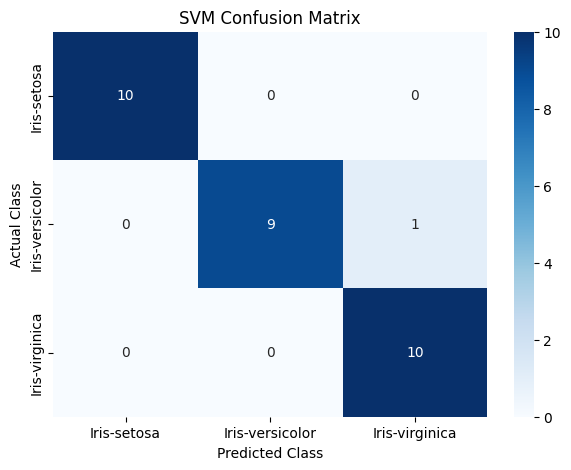

 Number of Support Vectors: 47

Support Vectors per Class:
[10 18 19]

New Flower:
Sepal Length = 5.1
Sepal width = 3.5
Petal Length = 1.4
Petal Width=0.2

Predicted Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


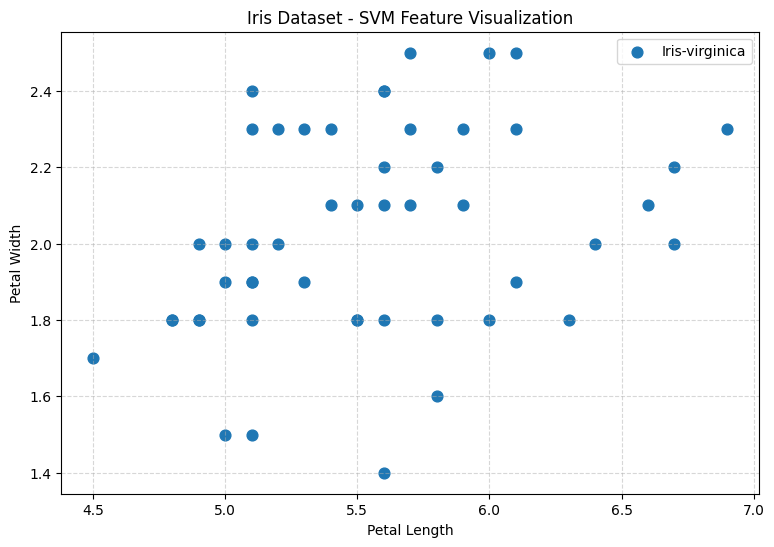


SVM PROJECT COMPLETED SUCCESSFULLY


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix
)
path="/kaggle/input/datasets/uciml/iris/Iris.csv"
iris=pd.read_csv(path)

print("=" * 60)
print("SVM CLASSIFICATION USING IRIS DATASET")
print("=" * 60)
print("/nDataset Shape:", iris.shape)
print("/nFirst 5 Rows:")
display(iris.head())

features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]
X= iris[features]
y= iris["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.20,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model=SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\SVM Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

print(" Number of Support Vectors:",
      len(svm_model.support_))
print("\nSupport Vectors per Class:")
print(svm_model.n_support_)

new_flower = [[5.1, 3.5, 1.4, 0.2]]

new_flower_scaled = scaler.transform(new_flower)

prediction = svm_model.predict(new_flower_scaled)

print("\nNew Flower:")
print("Sepal Length = 5.1")
print("Sepal width = 3.5")
print("Petal Length = 1.4")
print("Petal Width=0.2")

print("\nPredicted Species:", prediction[0])
plt.figure(figsize=(9,6))

for species in iris["Species"].unique():
    data=iris[iris["Species"]==species]

plt.scatter(
    data["PetalLengthCm"],
    data["PetalWidthCm"],
    s=60,
    label=species
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset - SVM Feature Visualization")
plt.legend()
plt.grid(True, linestyle="--",alpha=0.5)
plt.show()

print("\n" + "=" * 60)
print("SVM PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)